# Segmenter Training and Scene Diagnostics

This notebook trains or loads the small U-Net segmenter, then checks whether its masks actually help on full train scenes.

The crop-level metrics tell us whether the model learned the generated masks. The scene-level cells are the more important sanity check: they show candidate boxes, segmenter foreground, proposal-box filtering, and the crops that get sent to the classifier.

Only train images are used for debugging and tuning here. Test images should stay inference-only.

In [1]:
import csv
import sys
from collections import Counter
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.model_selection import train_test_split

from uno_vision.classification.predict import load_card_classifier
from uno_vision.paths import SEGMENTER_MODELS_DIR, TRAIN_CSV_PATH, TRAIN_IMAGES_DIR
from uno_vision.pipeline.cards import classify_regions, regions_from_proposal_boxes, split_probability_mask
from uno_vision.segmentation.data import IMG_SIZE, SegDataset, collect_segmentation_pairs
from uno_vision.segmentation.inference import load_segmenter, segment_image
from uno_vision.segmentation.model import UNetSmall
from uno_vision.segmentation.training import train_segmenter

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def tensor_to_rgb(img_t):
    img = img_t.detach().cpu().permute(1, 2, 0).numpy()
    return np.clip(img * STD + MEAN, 0.0, 1.0)


def iou_and_dice(pred_bin, gt_bin):
    inter = np.logical_and(pred_bin, gt_bin).sum()
    union = np.logical_or(pred_bin, gt_bin).sum()
    iou = float(inter / (union + 1e-8))
    dice = float((2.0 * inter) / (pred_bin.sum() + gt_bin.sum() + 1e-8))
    return iou, dice


def print_metric_summary(name, values):
    values = np.asarray(values, dtype=np.float32)
    print(
        f"{name:14s} mean={values.mean():.3f} median={np.median(values):.3f} "
        f"min={values.min():.3f} max={values.max():.3f}"
    )

model = UNetSmall()
param_count = sum(param.numel() for param in model.parameters() if param.requires_grad)
assert param_count <= 12_000_000, f"UNetSmall has {param_count:,} trainable params, above the 12M cap."

print(f"Project root: {PROJECT_ROOT}")
print(f"torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"[compliance] UNetSmall: {param_count:,} trainable params")
print(f"Model output directory: {SEGMENTER_MODELS_DIR}")

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo
torch: 2.11.0+cu128
CUDA available: True
[compliance] UNetSmall: 1,928,417 trainable params
Model output directory: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\artifacts\models\segmenter


In [2]:
pairs = collect_segmentation_pairs()
if not pairs:
    raise RuntimeError("No segmentation image-mask pairs found. Regenerate reference cards and augmentations first.")

source_counts = Counter("augmentation" if "augmentations" in image_path else "reference crop" for image_path, _ in pairs)

train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
)
train_ds = SegDataset(train_pairs, augment=True)
val_ds = SegDataset(val_pairs, augment=False)

with TRAIN_CSV_PATH.open(newline="", encoding="utf-8") as handle:
    train_labels = list(csv.DictReader(handle))

print("Segmentation pair sources:")
for source, count in source_counts.items():
    print(f"  {source:15s} {count:4d}")

print(f"Total segmentation pairs: {len(pairs)}")
print(f"Train pairs: {len(train_pairs)}")
print(f"Val pairs:   {len(val_pairs)}")
print(f"Image size used by SegDataset: {IMG_SIZE}")
print(f"Labeled train scenes: {len(train_labels)}")
print(f"Train image directory: {TRAIN_IMAGES_DIR}")

Segmentation pair sources:
  reference crop    54
  augmentation    1080
Total segmentation pairs: 1134
Train pairs: 907
Val pairs:   227
Image size used by SegDataset: 256
Labeled train scenes: 81
Train image directory: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\raw\train_images


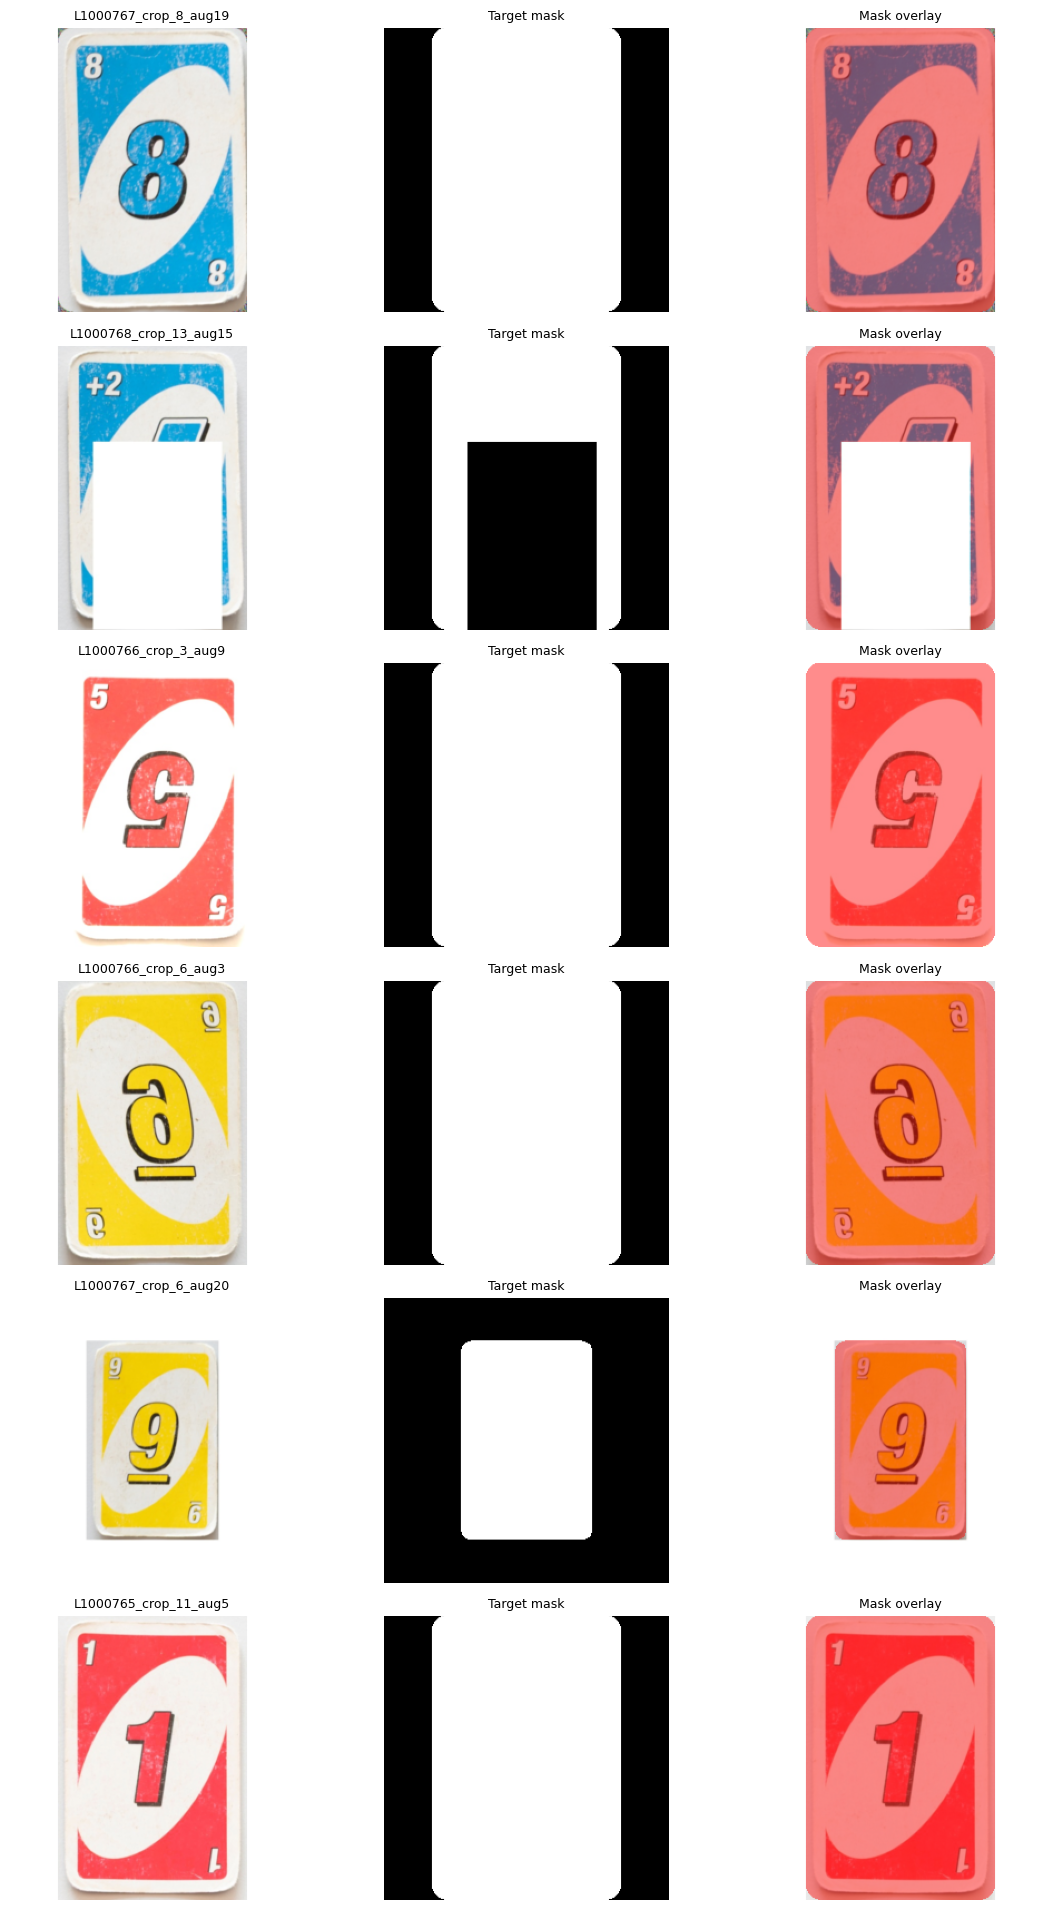

In [3]:
preview_count = min(6, len(val_ds))
fig, axes = plt.subplots(preview_count, 3, figsize=(12, 3.2 * preview_count), squeeze=False)

for row_idx in range(preview_count):
    img_t, mask_t = val_ds[row_idx]
    img_np = tensor_to_rgb(img_t)
    mask_np = mask_t[0].numpy() > 0.5
    overlay = img_np.copy()
    overlay[mask_np] = 0.55 * overlay[mask_np] + 0.45 * np.array([1.0, 0.0, 0.0])

    img_path, _ = val_pairs[row_idx]
    axes[row_idx, 0].imshow(img_np)
    axes[row_idx, 0].set_title(Path(img_path).stem, fontsize=9)
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(mask_np, cmap="gray", vmin=0, vmax=1)
    axes[row_idx, 1].set_title("Target mask", fontsize=9)
    axes[row_idx, 1].axis("off")

    axes[row_idx, 2].imshow(overlay)
    axes[row_idx, 2].set_title("Mask overlay", fontsize=9)
    axes[row_idx, 2].axis("off")

plt.tight_layout()
plt.show()

In [4]:
EPOCHS = 25
BATCH_SIZE = 8
RUN_TRAINING = True

if RUN_TRAINING:
    history = train_segmenter(
        pairs=pairs,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        random_state=SEED,
    )
    best_model_path = Path(history.model_path)
    print(f"Saved model: {history.model_path}")
    print(f"Best val IoU during training: {max(history.val_ious):.4f}")
else:
    history = None
    model_candidates = sorted(SEGMENTER_MODELS_DIR.glob("*.pth"), key=lambda path: path.stat().st_mtime, reverse=True)
    if not model_candidates:
        raise RuntimeError("No segmenter checkpoint found. Set RUN_TRAINING = True and run this cell.")
    best_model_path = model_candidates[0]
    print(f"Loaded existing model path: {best_model_path}")

00:20:16 | INFO | Segmenter training start | device=cuda | train_samples=907 | val_samples=227 | batch_size=8 | num_workers=4 | amp=True
00:20:57 | INFO | Segmenter epoch 1/25 | train=38.02s | val=2.50s | total=40.53s | train_loss=0.1760 | val_loss=0.0938 | train_iou=0.9402 | val_iou=0.9659
00:21:00 | INFO | Segmenter epoch 2/25 | train=2.97s | val=0.23s | total=3.20s | train_loss=0.0635 | val_loss=0.0535 | train_iou=0.9682 | val_iou=0.9718
00:21:03 | INFO | Segmenter epoch 3/25 | train=2.94s | val=0.23s | total=3.18s | train_loss=0.0539 | val_loss=0.2886 | train_iou=0.9648 | val_iou=0.8291
00:21:06 | INFO | Segmenter epoch 4/25 | train=2.95s | val=0.24s | total=3.18s | train_loss=0.0417 | val_loss=0.0318 | train_iou=0.9695 | val_iou=0.9803
00:21:09 | INFO | Segmenter epoch 5/25 | train=2.94s | val=0.23s | total=3.18s | train_loss=0.0287 | val_loss=0.0357 | train_iou=0.9778 | val_iou=0.9824
00:21:13 | INFO | Segmenter epoch 6/25 | train=2.96s | val=0.23s | total=3.19s | train_loss=0.02

Saved model: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\artifacts\models\segmenter\segmenter_unet_small.pth
Best val IoU during training: 0.9969


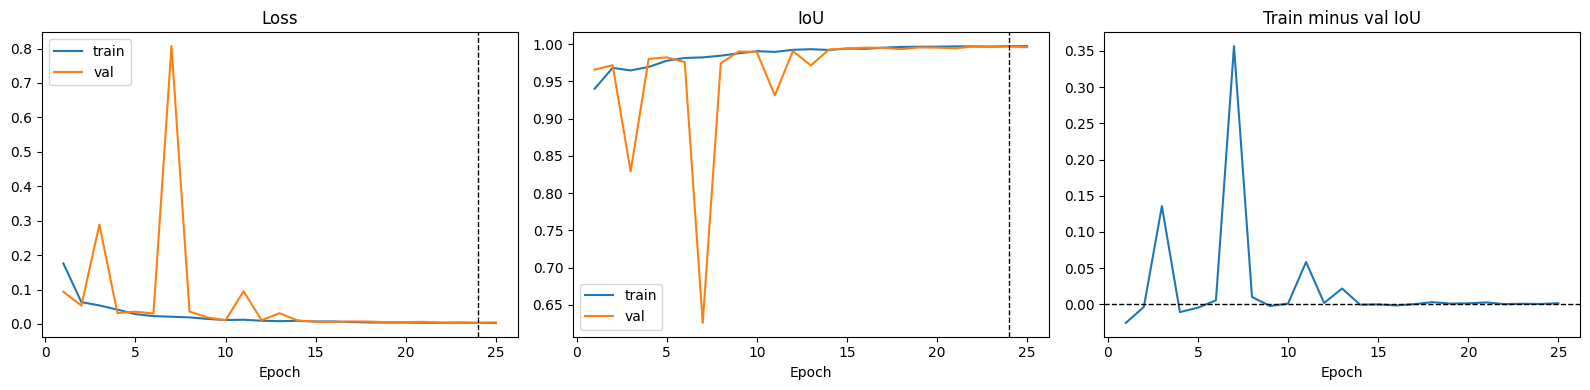

Best epoch by val IoU: 24
Best val IoU: 0.9969


In [5]:
if history is None:
    print("No training history in memory. Run with RUN_TRAINING = True to see curves.")
else:
    epochs = np.arange(1, len(history.train_losses) + 1)
    best_epoch = int(np.argmax(history.val_ious)) + 1

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, history.train_losses, label="train")
    axes[0].plot(epochs, history.val_losses, label="val")
    axes[0].axvline(best_epoch, color="black", linestyle="--", linewidth=1)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, history.train_ious, label="train")
    axes[1].plot(epochs, history.val_ious, label="val")
    axes[1].axvline(best_epoch, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("IoU")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    gap = np.array(history.train_ious) - np.array(history.val_ious)
    axes[2].plot(epochs, gap)
    axes[2].axhline(0.0, color="black", linestyle="--", linewidth=1)
    axes[2].set_title("Train minus val IoU")
    axes[2].set_xlabel("Epoch")

    plt.tight_layout()
    plt.show()

    print(f"Best epoch by val IoU: {best_epoch}")
    print(f"Best val IoU: {max(history.val_ious):.4f}")

IoU            mean=0.996 median=1.000 min=0.925 max=1.000
Dice           mean=0.998 median=1.000 min=0.961 max=1.000
GT fg frac     mean=0.598 median=0.661 min=0.301 max=0.664
Pred fg frac   mean=0.598 median=0.661 min=0.304 max=0.685


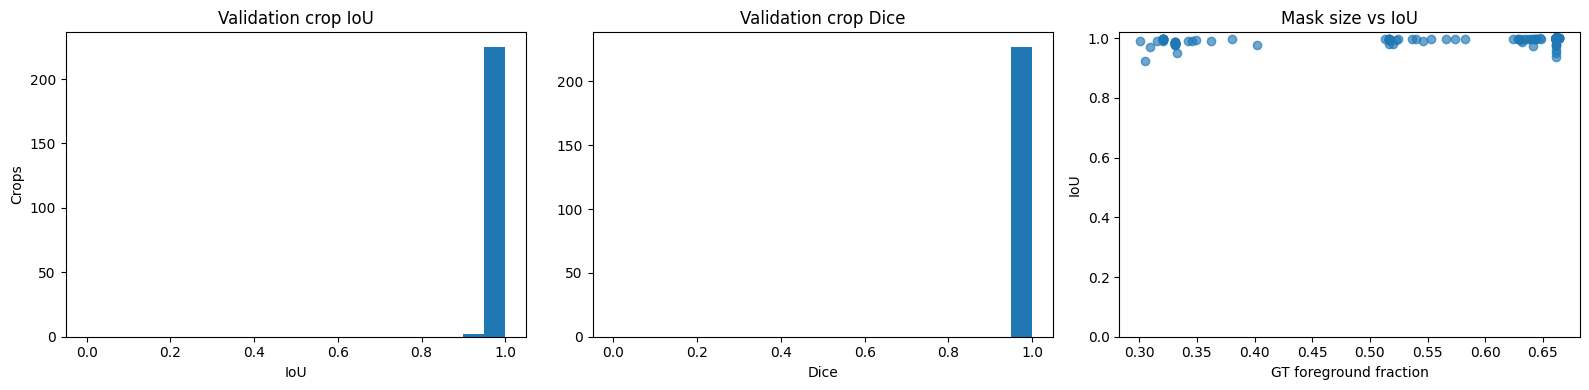

Loaded model: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\artifacts\models\segmenter\segmenter_unet_small.pth


In [6]:
if "best_model_path" not in globals():
    model_candidates = sorted(SEGMENTER_MODELS_DIR.glob("*.pth"), key=lambda path: path.stat().st_mtime, reverse=True)
    if not model_candidates:
        raise RuntimeError("No segmenter checkpoint found. Train the model first.")
    best_model_path = model_candidates[0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetSmall().to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

threshold = 0.5
crop_metrics = []

with torch.no_grad():
    for idx in range(len(val_ds)):
        img_t, mask_t = val_ds[idx]
        logits = model(img_t.unsqueeze(0).to(device))
        pred_prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()

        gt = mask_t[0].numpy() > 0.5
        pred = pred_prob > threshold
        iou, dice = iou_and_dice(pred, gt)
        img_path, mask_path = val_pairs[idx]
        crop_metrics.append({
            "idx": idx,
            "image": Path(img_path).name,
            "source": "augmentation" if "augmentations" in str(img_path) else "reference",
            "iou": iou,
            "dice": dice,
            "gt_fg_frac": float(gt.mean()),
            "pred_fg_frac": float(pred.mean()),
            "mask": Path(mask_path).name,
        })

ious = np.array([row["iou"] for row in crop_metrics])
dices = np.array([row["dice"] for row in crop_metrics])
gt_fracs = np.array([row["gt_fg_frac"] for row in crop_metrics])
pred_fracs = np.array([row["pred_fg_frac"] for row in crop_metrics])

print_metric_summary("IoU", ious)
print_metric_summary("Dice", dices)
print_metric_summary("GT fg frac", gt_fracs)
print_metric_summary("Pred fg frac", pred_fracs)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(ious, bins=20, range=(0, 1))
axes[0].set_title("Validation crop IoU")
axes[0].set_xlabel("IoU")
axes[0].set_ylabel("Crops")

axes[1].hist(dices, bins=20, range=(0, 1))
axes[1].set_title("Validation crop Dice")
axes[1].set_xlabel("Dice")

axes[2].scatter(gt_fracs, ious, alpha=0.65)
axes[2].set_title("Mask size vs IoU")
axes[2].set_xlabel("GT foreground fraction")
axes[2].set_ylabel("IoU")
axes[2].set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

print(f"Loaded model: {best_model_path}")

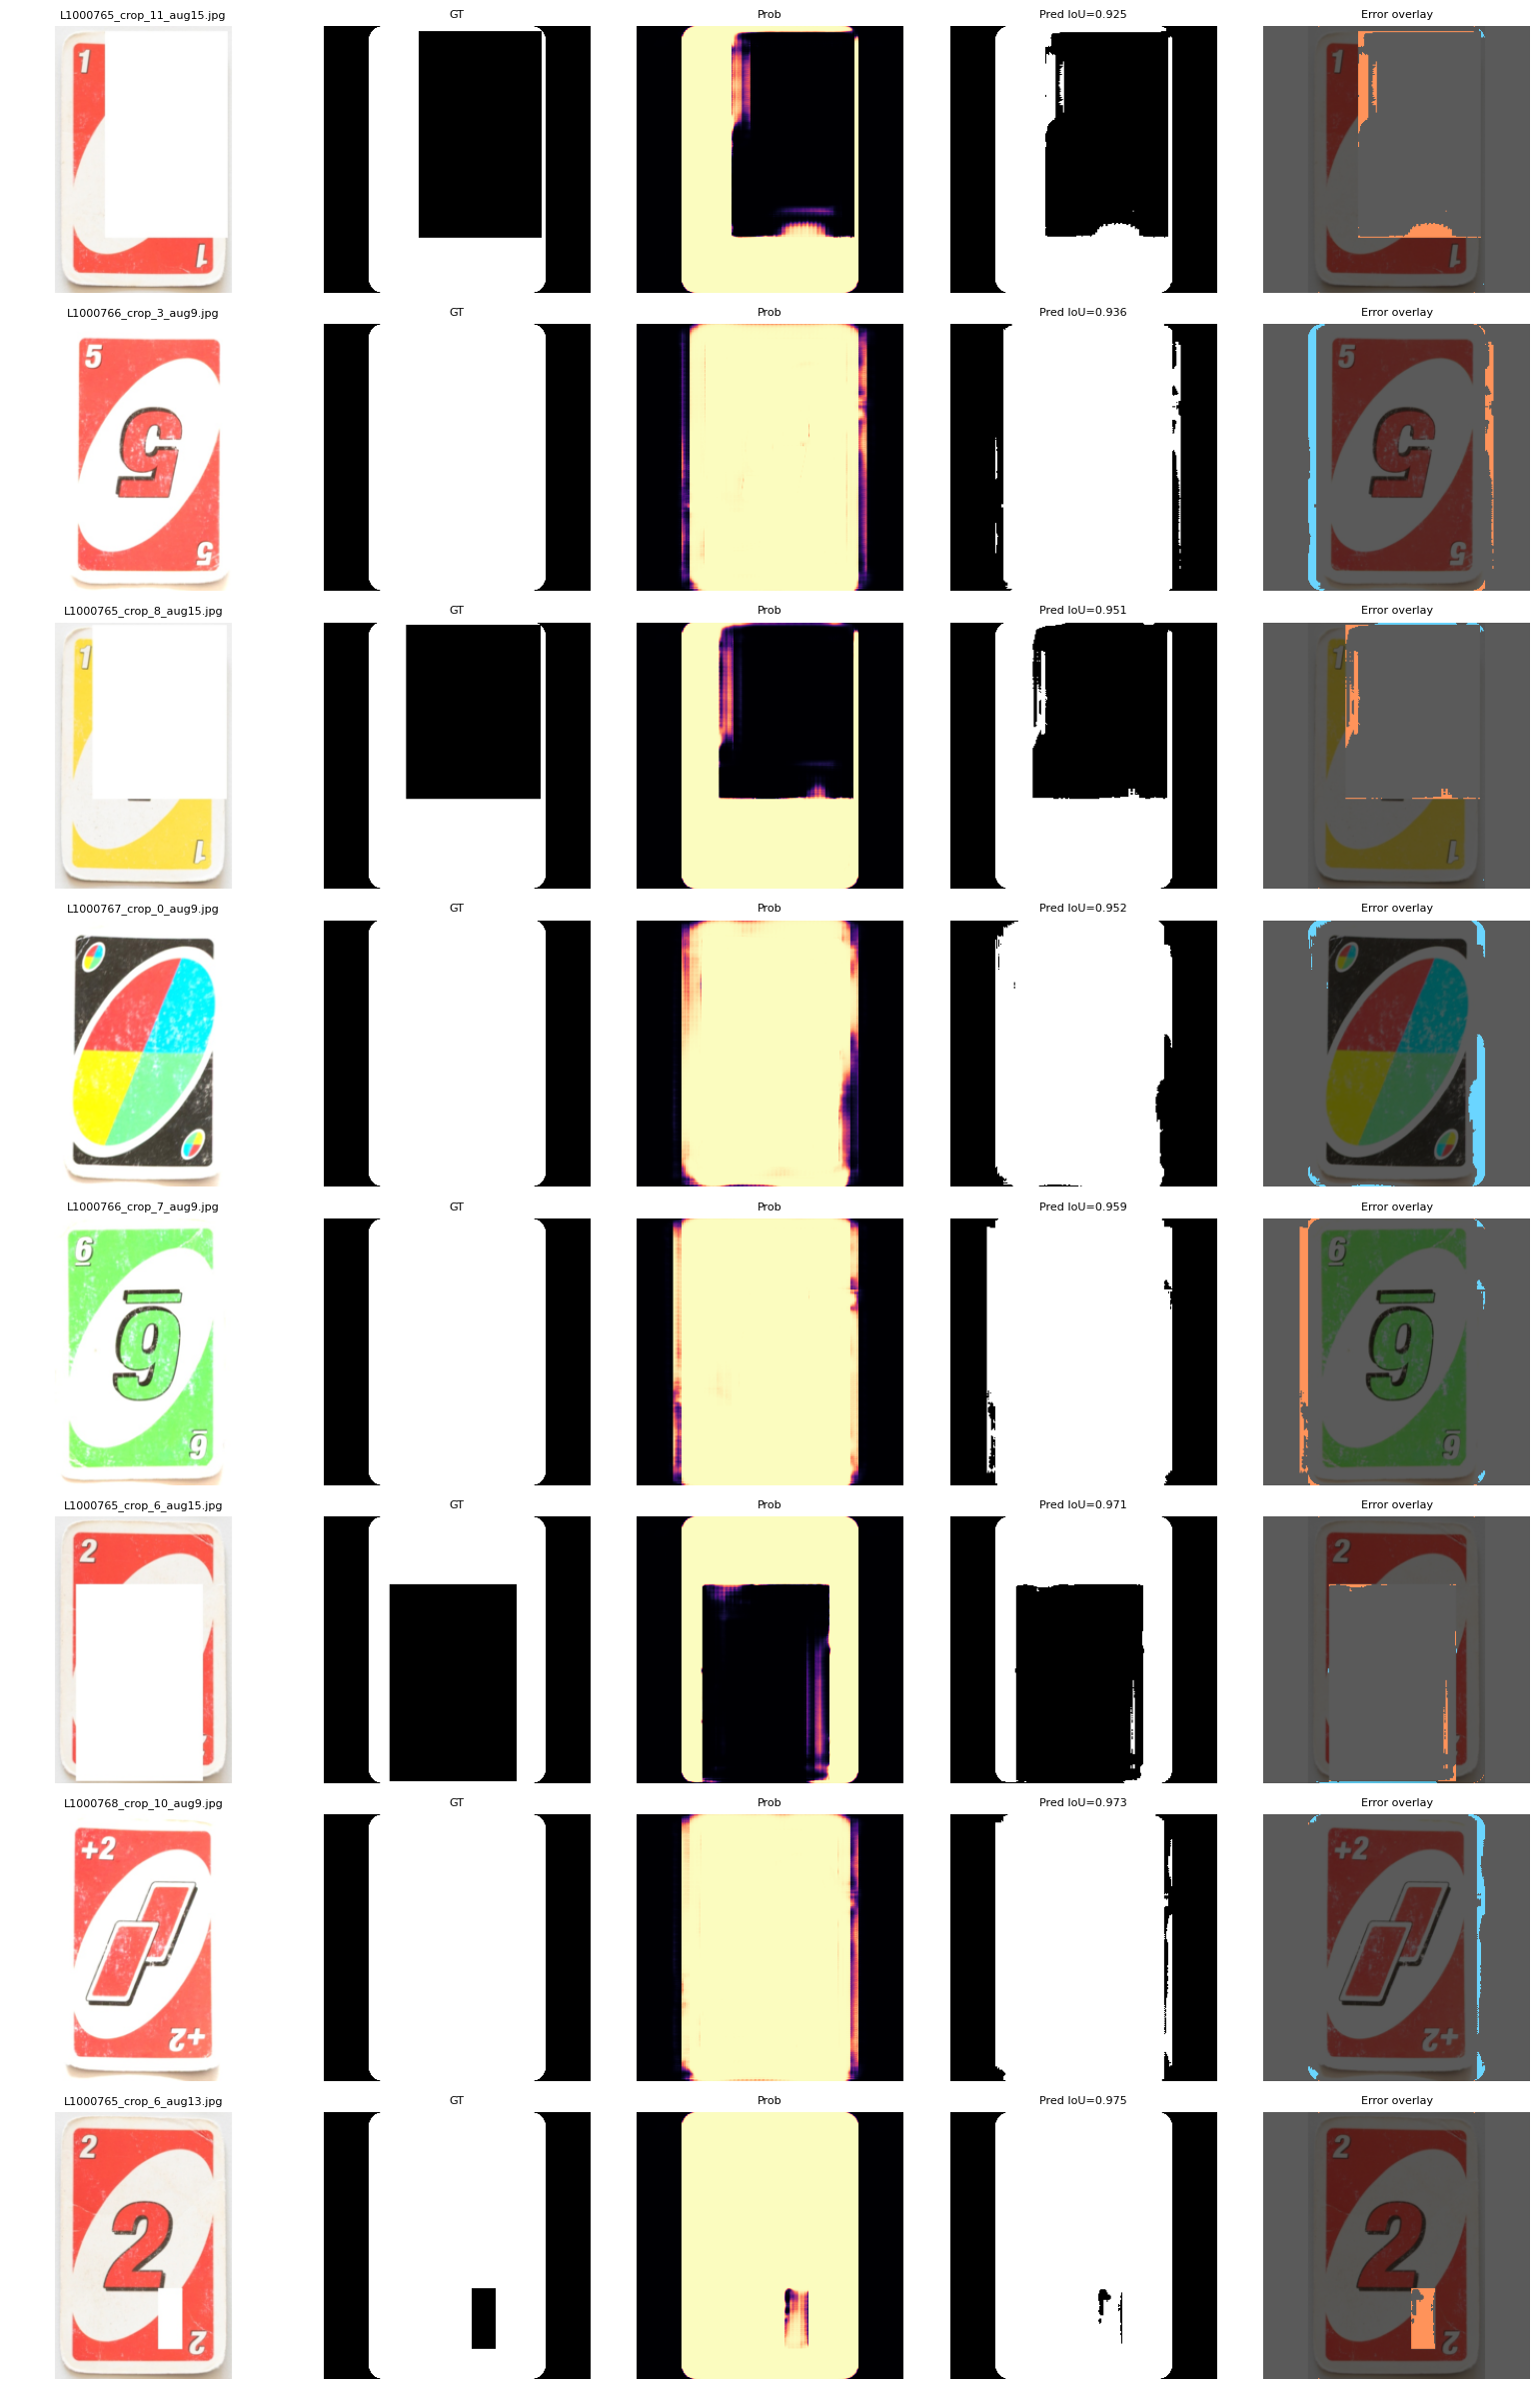

In [7]:
if "crop_metrics" not in globals():
    raise RuntimeError("Run the crop metrics cell first.")

worst = sorted(crop_metrics, key=lambda row: row["iou"])[: min(8, len(crop_metrics))]
fig, axes = plt.subplots(len(worst), 5, figsize=(16, 3.0 * len(worst)), squeeze=False)

with torch.no_grad():
    for row_idx, metric_row in enumerate(worst):
        idx = int(metric_row["idx"])
        img_t, mask_t = val_ds[idx]
        logits = model(img_t.unsqueeze(0).to(device))
        pred_prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()

        img_np = tensor_to_rgb(img_t)
        gt = mask_t[0].numpy() > 0.5
        pred = pred_prob > threshold

        fp = np.logical_and(pred, np.logical_not(gt))
        fn = np.logical_and(np.logical_not(pred), gt)
        diff = np.zeros((*gt.shape, 3), dtype=np.float32)
        diff[fp] = [1.0, 0.35, 0.0]
        diff[fn] = [0.1, 0.75, 1.0]

        axes[row_idx, 0].imshow(img_np)
        axes[row_idx, 0].set_title(metric_row["image"], fontsize=8)
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(gt, cmap="gray", vmin=0, vmax=1)
        axes[row_idx, 1].set_title("GT", fontsize=8)
        axes[row_idx, 1].axis("off")

        axes[row_idx, 2].imshow(pred_prob, cmap="magma", vmin=0, vmax=1)
        axes[row_idx, 2].set_title("Prob", fontsize=8)
        axes[row_idx, 2].axis("off")

        axes[row_idx, 3].imshow(pred, cmap="gray", vmin=0, vmax=1)
        axes[row_idx, 3].set_title(f"Pred IoU={metric_row['iou']:.3f}", fontsize=8)
        axes[row_idx, 3].axis("off")

        axes[row_idx, 4].imshow(img_np)
        axes[row_idx, 4].imshow(diff, alpha=0.65)
        axes[row_idx, 4].set_title("Error overlay", fontsize=8)
        axes[row_idx, 4].axis("off")

plt.tight_layout()
plt.show()

Scene model: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\artifacts\models\segmenter\segmenter_unet_small.pth
image_id  exp coarse prop mask pred match err precision recall invalid
L1000770   7      7    7    4    7     2   0     0.286  0.286       1
L1000771   6      8    8    6    8     5   2     0.625  0.833       0
L1000772  12     10   10    6   10     1   2     0.100  0.083       1
L1000773   9      8    8    6    8     2   1     0.250  0.222       0
L1000774  12     16   16    8   16     4   4     0.250  0.333       0
L1000775  12     13   13    9   13     4   1     0.308  0.333       1
L1000776   9     10   10    5   10     5   1     0.500  0.556       2
L1000777   7      7    7    5    7     2   0     0.286  0.286       0
L1000778   8      9    9    6    9     2   1     0.222  0.250       0
L1000779   7      8    8    5    8     3   1     0.375  0.429       0
L1000780   7      9    9    6    9     4   2     0.444  0.571       0
L1000781   6     10   10    5   10     2  

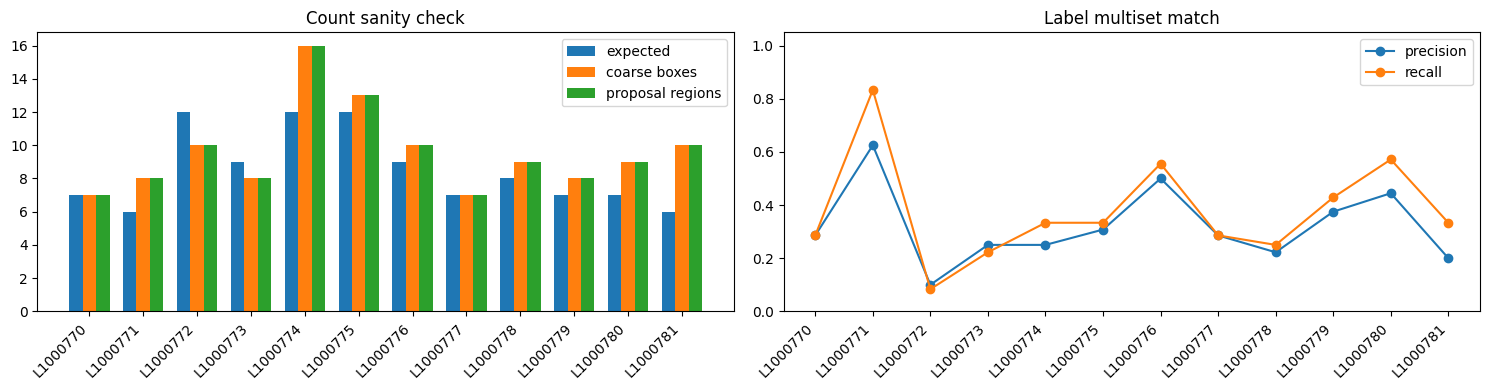

In [8]:
COLORS = {"r", "g", "b", "y"}
RANKS = {"0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "skip", "reverse", "draw_2"}
SPECIAL_CARDS = {"wild", "draw_4"}


def split_cards(value):
    return [] if value == "EMPTY" else value.split(";")


def expected_cards(row):
    cards = []
    if row["center_card"] != "EMPTY":
        cards.append(row["center_card"])
    for key in ("player_1_cards", "player_2_cards", "player_3_cards", "player_4_cards"):
        cards.extend(split_cards(row[key]))
    return cards


def is_valid_card_label(label):
    if label in SPECIAL_CARDS:
        return True
    if "_" not in label:
        return False
    color, rank = label.split("_", 1)
    return color in COLORS and rank in RANKS


scene_model, scene_device, scene_model_path = load_segmenter(best_model_path)
classifier = load_card_classifier()


def run_scene_row(row, max_components=24, proposal_prob_thresh=0.35, high_prob_thresh=0.65):
    image_id = row["image_id"]
    img_bgr = cv2.imread(str(TRAIN_IMAGES_DIR / f"{image_id}.jpg"))
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read train image: {image_id}")

    global_prob, boxes, binary_dbg, masks_dbg = segment_image(img_bgr, scene_model, scene_device, max_components=max_components)
    proposal_regions = regions_from_proposal_boxes(global_prob, boxes, prob_thresh=proposal_prob_thresh)
    _, mask_regions = split_probability_mask(global_prob, high_prob_thresh=high_prob_thresh)
    predictions = classify_regions(img_bgr, proposal_regions, classifier)

    expected = expected_cards(row)
    predicted = [pred.label for pred in predictions]
    expected_counter = Counter(expected)
    predicted_counter = Counter(predicted)
    matched = sum((expected_counter & predicted_counter).values())
    missing = list((expected_counter - predicted_counter).elements())
    extra = list((predicted_counter - expected_counter).elements())
    invalid = [label for label in predicted if not is_valid_card_label(label)]

    return {
        "image_id": image_id,
        "img_bgr": img_bgr,
        "global_prob": global_prob,
        "boxes": boxes,
        "binary_dbg": binary_dbg,
        "masks_dbg": masks_dbg,
        "proposal_regions": proposal_regions,
        "mask_regions": mask_regions,
        "predictions": predictions,
        "expected": expected,
        "predicted": predicted,
        "matched": matched,
        "missing": missing,
        "extra": extra,
        "invalid": invalid,
    }

SCENE_LIMIT = 12
scene_results = [run_scene_row(row) for row in train_labels[:SCENE_LIMIT]]

scene_report = []
for result in scene_results:
    expected_count = len(result["expected"])
    predicted_count = len(result["predicted"])
    scene_report.append({
        "image_id": result["image_id"],
        "expected": expected_count,
        "coarse_boxes": len(result["boxes"]),
        "proposal_regions": len(result["proposal_regions"]),
        "mask_regions": len(result["mask_regions"]),
        "predicted": predicted_count,
        "matched": result["matched"],
        "count_error": abs(expected_count - predicted_count),
        "precision": result["matched"] / max(1, predicted_count),
        "recall": result["matched"] / max(1, expected_count),
        "invalid": len(result["invalid"]),
    })

print(f"Scene model: {scene_model_path}")
print("image_id  exp coarse prop mask pred match err precision recall invalid")
for row in scene_report:
    print(
        f"{row['image_id']:8s} {row['expected']:3d} {row['coarse_boxes']:6d} "
        f"{row['proposal_regions']:4d} {row['mask_regions']:4d} {row['predicted']:4d} "
        f"{row['matched']:5d} {row['count_error']:3d} {row['precision']:9.3f} "
        f"{row['recall']:6.3f} {row['invalid']:7d}"
    )

avg_count_error = np.mean([row["count_error"] for row in scene_report])
mean_precision = np.mean([row["precision"] for row in scene_report])
mean_recall = np.mean([row["recall"] for row in scene_report])
print(f"Average count error: {avg_count_error:.2f} cards/image")
print(f"Mean label precision: {mean_precision:.3f}")
print(f"Mean label recall: {mean_recall:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
x = np.arange(len(scene_report))
image_ids = [row["image_id"] for row in scene_report]
axes[0].bar(x - 0.25, [row["expected"] for row in scene_report], width=0.25, label="expected")
axes[0].bar(x, [row["coarse_boxes"] for row in scene_report], width=0.25, label="coarse boxes")
axes[0].bar(x + 0.25, [row["proposal_regions"] for row in scene_report], width=0.25, label="proposal regions")
axes[0].set_xticks(x)
axes[0].set_xticklabels(image_ids, rotation=45, ha="right")
axes[0].set_title("Count sanity check")
axes[0].legend()

axes[1].plot(x, [row["precision"] for row in scene_report], marker="o", label="precision")
axes[1].plot(x, [row["recall"] for row in scene_report], marker="o", label="recall")
axes[1].set_xticks(x)
axes[1].set_xticklabels(image_ids, rotation=45, ha="right")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Label multiset match")
axes[1].legend()

plt.tight_layout()
plt.show()

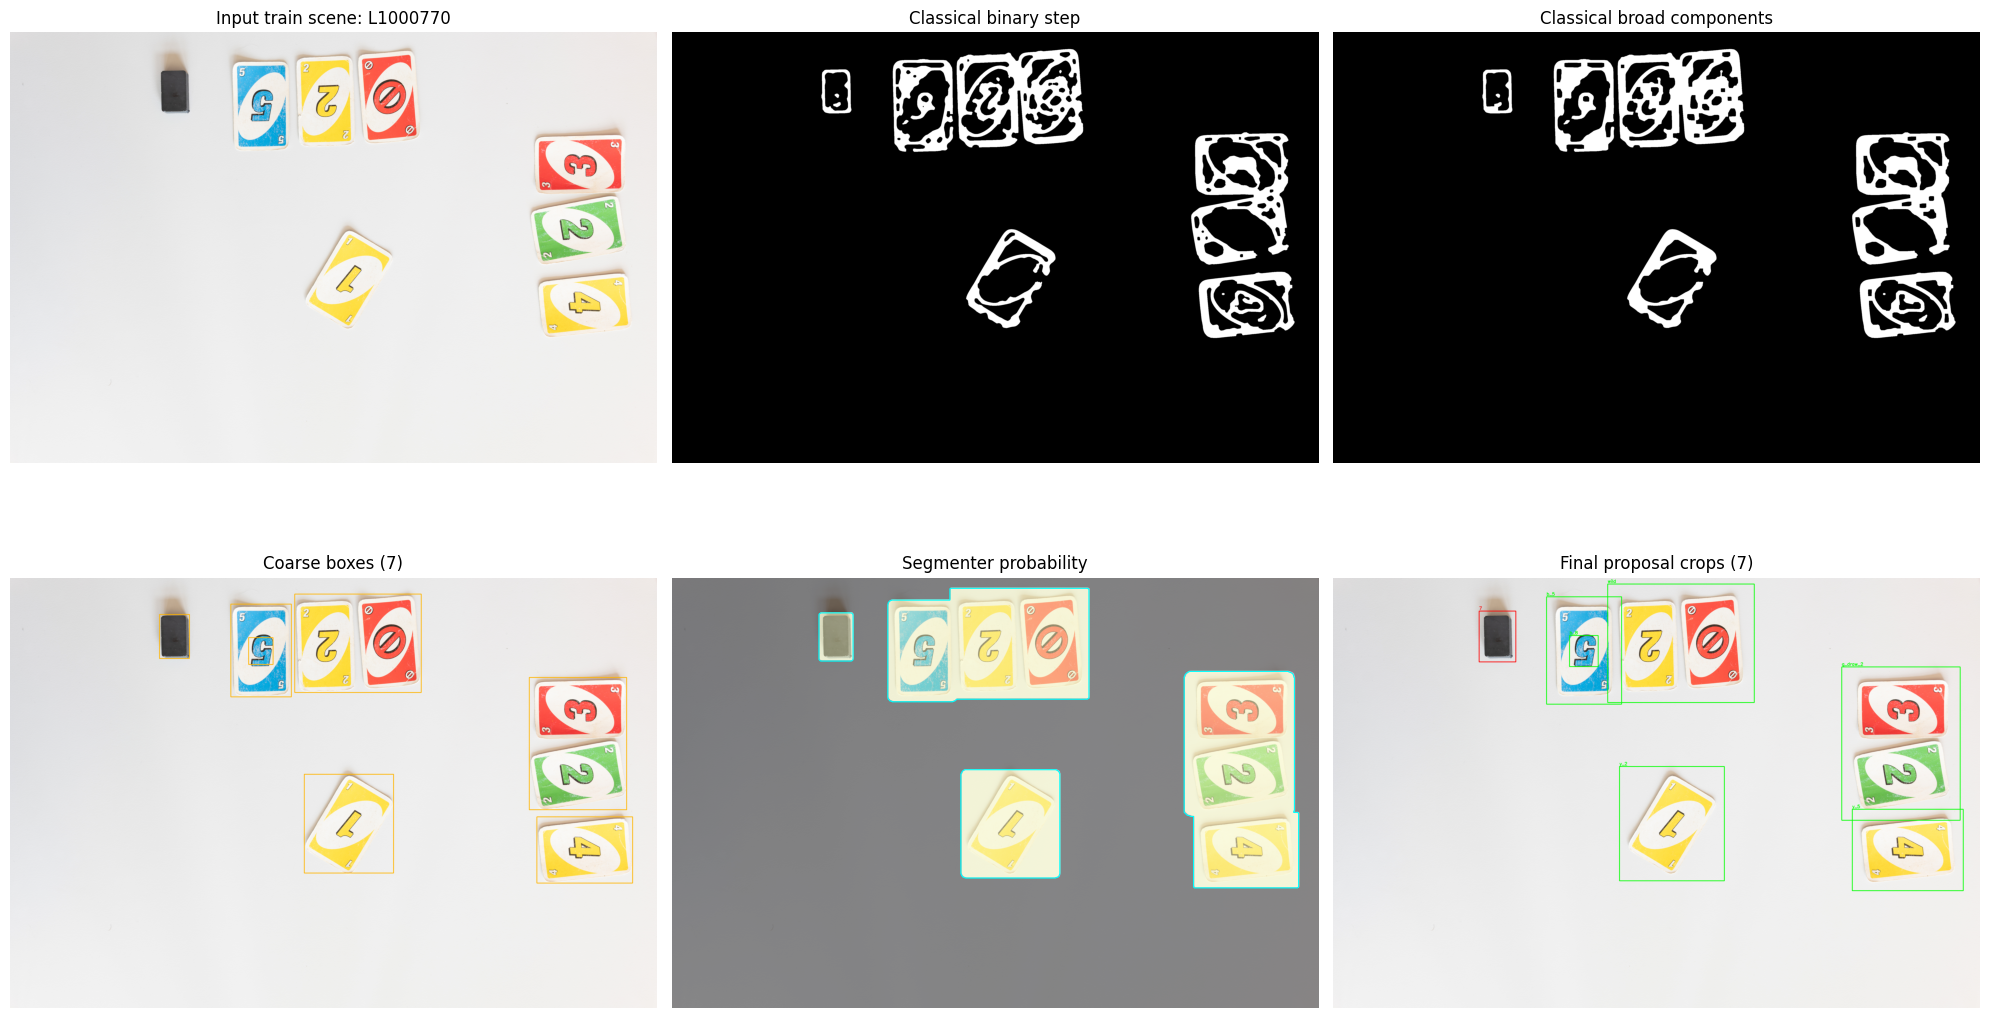

Expected: y_1;y_4;g_2;r_3;r_skip;y_2;b_5
Predicted: g_draw_2;wild;y_2;y_5;b_5;7;b_8
Missing: y_1;y_4;g_2;r_3;r_skip
Extra: g_draw_2;wild;y_5;7;b_8
Invalid: 7


In [9]:
scene_index = 0
scene_debug = scene_results[scene_index]
img_rgb = cv2.cvtColor(scene_debug["img_bgr"], cv2.COLOR_BGR2RGB)

coarse_boxed = img_rgb.copy()
for x, y, w, h in scene_debug["boxes"]:
    cv2.rectangle(coarse_boxed, (x, y), (x + w, y + h), (255, 180, 0), 3)

proposal_boxed = img_rgb.copy()
for x, y, w, h, _, _ in scene_debug["proposal_regions"]:
    cv2.rectangle(proposal_boxed, (x, y), (x + w, y + h), (0, 255, 0), 3)

prediction_boxed = img_rgb.copy()
for pred in scene_debug["predictions"]:
    x0, y0, x1, y1 = pred.box
    color = (0, 255, 0) if is_valid_card_label(pred.label) else (255, 0, 0)
    cv2.rectangle(prediction_boxed, (x0, y0), (x1, y1), color, 3)
    cv2.putText(
        prediction_boxed,
        pred.label,
        (x0, max(25, y0 - 8)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        color,
        2,
        cv2.LINE_AA,
    )

mask_bin = scene_debug["global_prob"] > 0.5

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.reshape(-1)

axes[0].imshow(img_rgb)
axes[0].set_title(f"Input train scene: {scene_debug['image_id']}")
axes[0].axis("off")

axes[1].imshow(scene_debug["binary_dbg"], cmap="gray")
axes[1].set_title("Classical binary step")
axes[1].axis("off")

axes[2].imshow(scene_debug["masks_dbg"], cmap="gray")
axes[2].set_title("Classical broad components")
axes[2].axis("off")

axes[3].imshow(coarse_boxed)
axes[3].set_title(f"Coarse boxes ({len(scene_debug['boxes'])})")
axes[3].axis("off")

axes[4].imshow(img_rgb)
axes[4].imshow(scene_debug["global_prob"], cmap="magma", alpha=0.45, vmin=0, vmax=1)
axes[4].contour(mask_bin, colors="cyan", linewidths=0.8)
axes[4].set_title("Segmenter probability")
axes[4].axis("off")

axes[5].imshow(prediction_boxed)
axes[5].set_title(f"Final proposal crops ({len(scene_debug['predictions'])})")
axes[5].axis("off")

plt.tight_layout()
plt.show()

print("Expected:", ";".join(scene_debug["expected"]))
print("Predicted:", ";".join(scene_debug["predicted"]))
print("Missing:", ";".join(scene_debug["missing"]) if scene_debug["missing"] else "-")
print("Extra:", ";".join(scene_debug["extra"]) if scene_debug["extra"] else "-")
print("Invalid:", ";".join(scene_debug["invalid"]) if scene_debug["invalid"] else "-")

threshold  avg_regions  avg_count_error
     0.20         9.58             1.58
     0.30         9.58             1.58
     0.35         9.58             1.58
     0.45         9.58             1.58
     0.55         9.58             1.58
     0.65         9.58             1.58


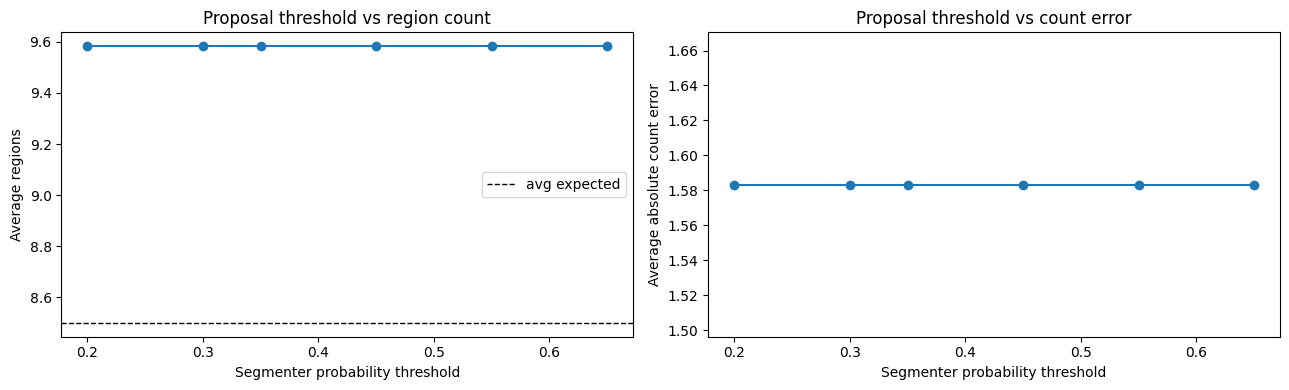

In [10]:
thresholds = [0.20, 0.30, 0.35, 0.45, 0.55, 0.65]
threshold_rows = []

for result in scene_results:
    expected_count = len(result["expected"])
    for thresh in thresholds:
        regions = regions_from_proposal_boxes(result["global_prob"], result["boxes"], prob_thresh=thresh)
        threshold_rows.append({
            "image_id": result["image_id"],
            "threshold": thresh,
            "regions": len(regions),
            "expected": expected_count,
            "abs_count_error": abs(expected_count - len(regions)),
        })

threshold_summary = []
for thresh in thresholds:
    rows = [row for row in threshold_rows if row["threshold"] == thresh]
    threshold_summary.append({
        "threshold": thresh,
        "avg_regions": float(np.mean([row["regions"] for row in rows])),
        "avg_count_error": float(np.mean([row["abs_count_error"] for row in rows])),
    })

print("threshold  avg_regions  avg_count_error")
for row in threshold_summary:
    print(f"{row['threshold']:9.2f} {row['avg_regions']:12.2f} {row['avg_count_error']:16.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot([row["threshold"] for row in threshold_summary], [row["avg_regions"] for row in threshold_summary], marker="o")
axes[0].axhline(np.mean([row["expected"] for row in scene_report]), color="black", linestyle="--", linewidth=1, label="avg expected")
axes[0].set_title("Proposal threshold vs region count")
axes[0].set_xlabel("Segmenter probability threshold")
axes[0].set_ylabel("Average regions")
axes[0].legend()

axes[1].plot([row["threshold"] for row in threshold_summary], [row["avg_count_error"] for row in threshold_summary], marker="o")
axes[1].set_title("Proposal threshold vs count error")
axes[1].set_xlabel("Segmenter probability threshold")
axes[1].set_ylabel("Average absolute count error")

plt.tight_layout()
plt.show()

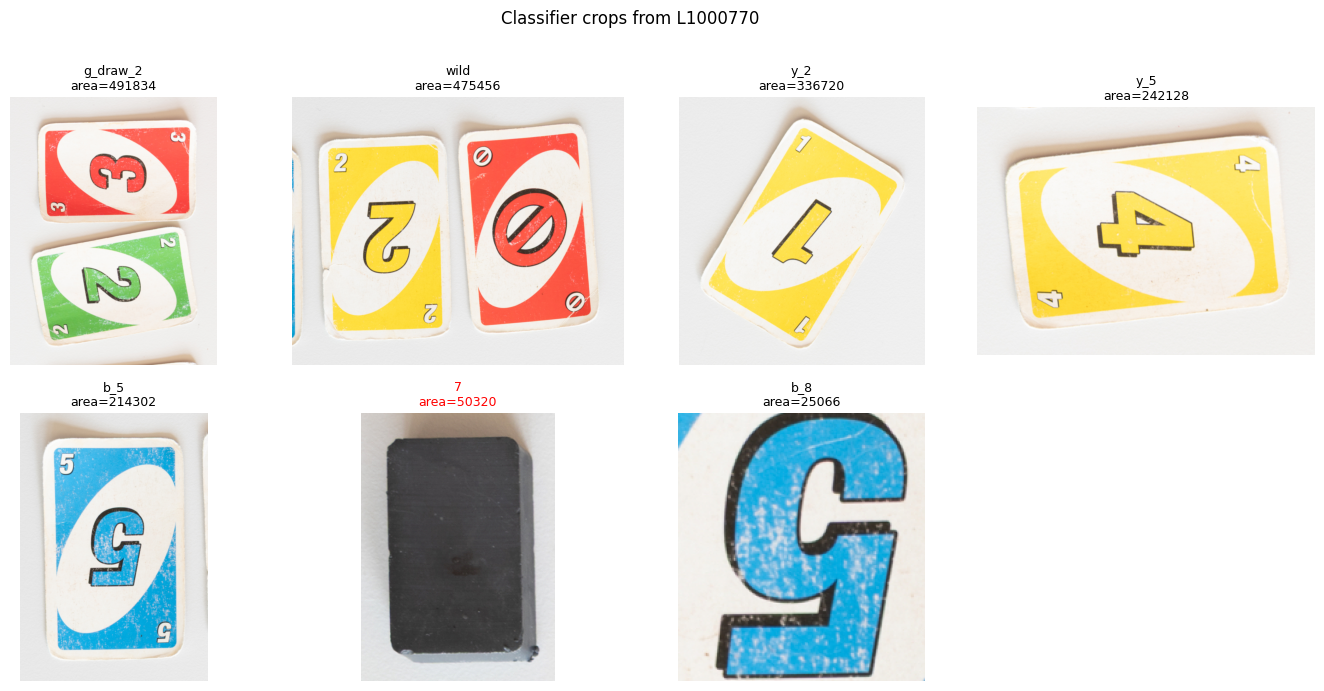

In [11]:
scene_index = 0
scene_debug = scene_results[scene_index]
predictions = scene_debug["predictions"]

if not predictions:
    print("No prediction crops for this scene.")
else:
    cols = 4
    rows = int(np.ceil(len(predictions) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.4 * rows), squeeze=False)
    axes = axes.reshape(-1)

    for ax, pred in zip(axes, predictions):
        x0, y0, x1, y1 = pred.box
        crop_rgb = cv2.cvtColor(scene_debug["img_bgr"][y0:y1, x0:x1], cv2.COLOR_BGR2RGB)
        ax.imshow(crop_rgb)
        title_color = "black" if is_valid_card_label(pred.label) else "red"
        ax.set_title(f"{pred.label}\narea={pred.area}", fontsize=9, color=title_color)
        ax.axis("off")

    for ax in axes[len(predictions):]:
        ax.axis("off")

    plt.suptitle(f"Classifier crops from {scene_debug['image_id']}", y=1.01)
    plt.tight_layout()
    plt.show()